In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

In [10]:
#Analysing the dataset
df.head()
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [11]:
#Data processing

df.isnull().sum()

df.duplicated().sum()
df.sample(10)

#Data is already cleaned

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
667,2023,3,Middle East,Model 3,10215,11462,104380.22,82,483,740.08,Estimated (Region),11496
617,2025,11,North America,Model Y,11488,12841,58543.76,60,335,577.27,Estimated (Region),5538
520,2019,11,Middle East,Cybertruck,10931,11121,117908.18,82,451,739.48,Estimated (Region),12632
1887,2023,3,North America,Cybertruck,11124,11921,65644.60,75,438,730.85,Estimated (Region),5289
1343,2018,11,North America,Model 3,10848,11734,61191.58,82,479,779.43,Estimated (Region),5010
846,2024,10,Asia,Model S,10792,10895,100028.12,82,472,764.07,Interpolated (Month),13810
2311,2016,8,Middle East,Cybertruck,14320,14659,98712.94,60,353,758.24,Estimated (Region),6801
1323,2023,3,Asia,Model X,6987,7810,76386.50,82,455,476.86,Interpolated (Month),10605
1648,2025,3,Europe,Model X,10895,11081,55876.62,100,566,924.99,Official (Quarter),6730
1999,2023,4,North America,Cybertruck,9117,9938,72916.37,120,706,965.49,Official (Quarter),13085


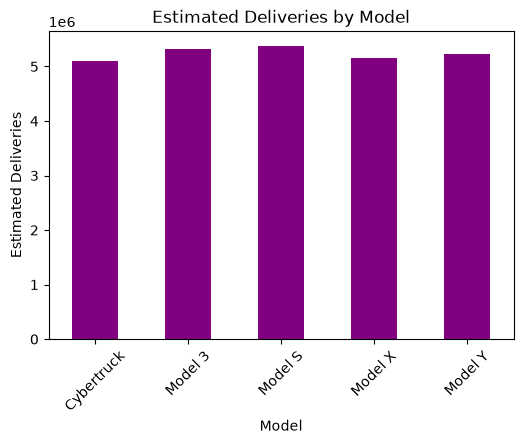

In [16]:
#EDA 
#Estimated delivereies by model
deliveries_by_model = df.groupby('Model')['Estimated_Deliveries'].sum()
plt.figure(figsize= (6,4))
deliveries_by_model.plot(kind = 'bar', color = 'purple')

plt.title('Estimated Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Estimated Deliveries')
plt.xticks(rotation=45)
plt.show()

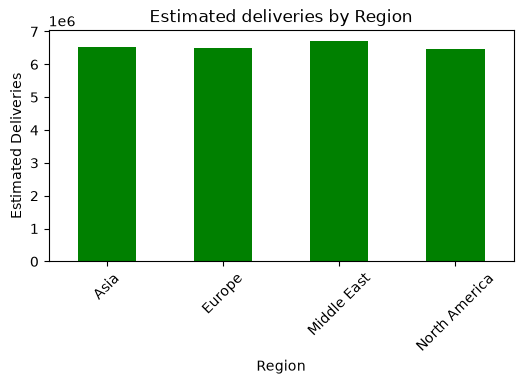

In [27]:
#Estimated Deliveries by Region

deliveries_by_region = df.groupby('Region')['Estimated_Deliveries'].sum()
plt.figure(figsize=(6,3))
deliveries_by_region.plot(kind = 'bar', color = 'green')

plt.title('Estimated deliveries by Region')
plt.xlabel('Region')
plt.xticks(rotation = 45)
plt.ylabel('Estimated Deliveries')
plt.show()

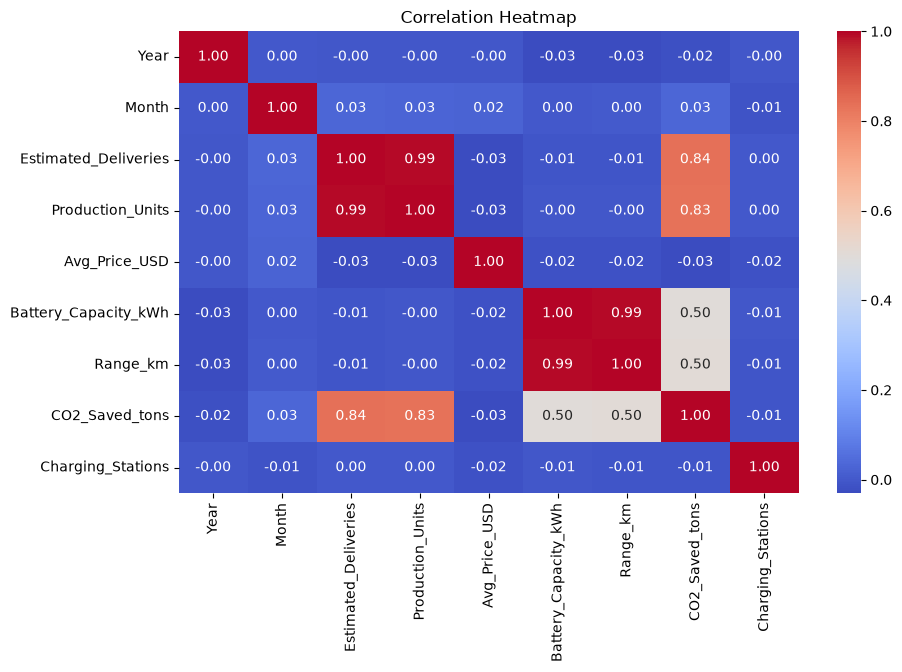

In [31]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

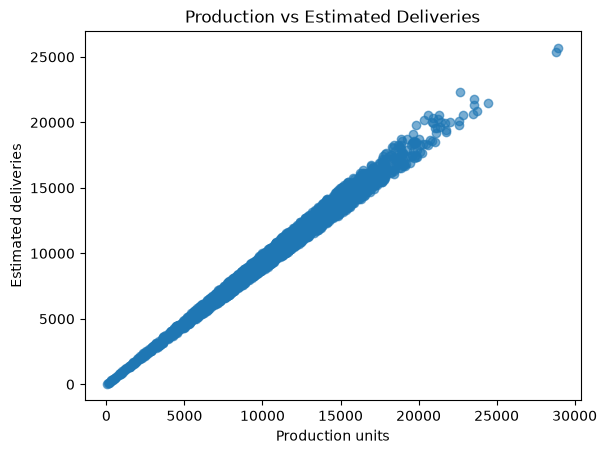

In [36]:
#Production vs Deliveries
plt.scatter(df['Production_Units'], df['Estimated_Deliveries'], alpha = 0.6)
plt.title('Production vs Estimated Deliveries')
plt.xlabel('Production units')
plt.ylabel('Estimated deliveries')
plt.show()

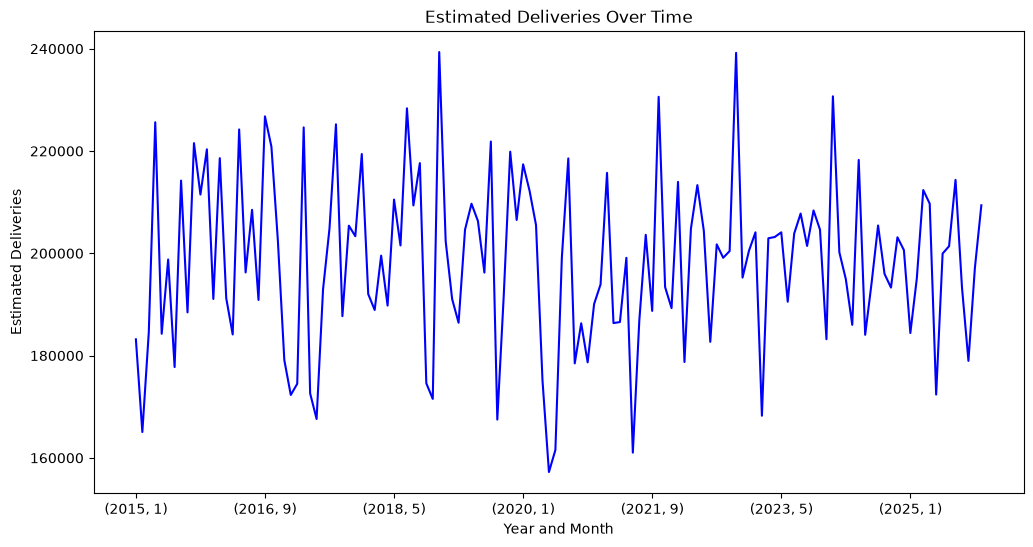

In [40]:
#delivereis over time
monthly_delivery = df.groupby(['Year','Month'])['Estimated_Deliveries'].sum()
plt.figure(figsize=(12,6))
monthly_delivery.plot(color='blue')

plt.title("Estimated Deliveries Over Time")
plt.xlabel("Year and Month")
plt.ylabel("Estimated Deliveries")

plt.show()

In [42]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])
df['Model'] = le_model.fit_transform(df['Model'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])

#Sorting chronologically
df = df.sort_values(['Year', 'Month']).reset_index(drop=True)

#Lag Feature
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)
df['Deliveries_Lag1'] = df['Deliveries_Lag1'].fillna(df['Deliveries_Lag1'].mean())

# Rolling Mean 
df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(window=3).mean()
df['Rolling_Mean_3'] = df['Rolling_Mean_3'].fillna(df['Rolling_Mean_3'].mean())
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Deliveries_Lag1,Rolling_Mean_3
0,2015,1,2,4,10348,10835,85599.95,82,488,757.47,0,5991,9921.649488,9921.864797
1,2015,1,0,4,12446,13885,55183.13,60,340,634.75,2,4390,10348.000000,9921.864797
2,2015,1,1,4,10835,11723,62939.81,120,718,1166.93,2,12301,12446.000000,11209.666667
3,2015,1,3,3,8122,8343,62838.32,75,423,515.34,2,9297,10835.000000,10467.666667
4,2015,1,2,2,13902,15423,94629.02,75,445,927.96,2,8666,8122.000000,10953.000000


In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df.drop(columns=['Estimated_Deliveries'])
y = df['Estimated_Deliveries']

# Chronological Split
split = int(len(df) * 0.8)
X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

lr = LinearRegression()
lr.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [46]:
y_pred = lr.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE: ", mae)
print("RMSE: ", rmse)
print("R2: ", r2)

MAE:  317.9318141670008
RMSE:  386.69473579843196
R2:  0.9888858920489445


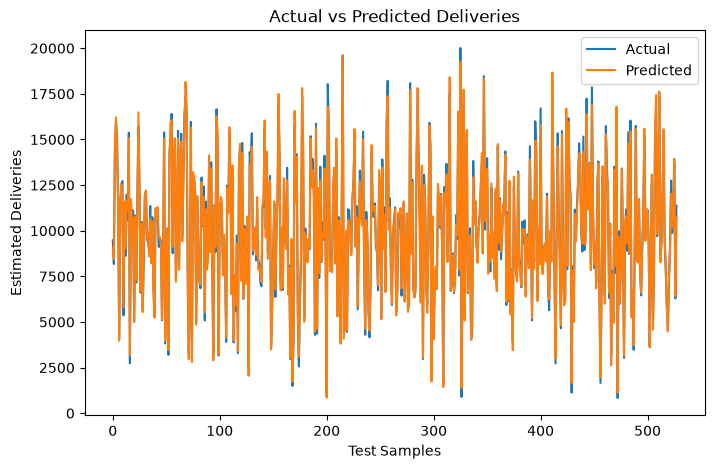

In [47]:
#Actual vs predicted
plt.figure(figsize=(8,5))

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.title("Actual vs Predicted Deliveries")
plt.xlabel("Test Samples")
plt.ylabel("Estimated Deliveries")

plt.legend()

plt.show()

In [60]:
#cross validation
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    lr,
    X,
    y,
    cv=kf,
    scoring='r2'
)

for i, score in enumerate(scores):
    print(f"Fold {i+1} R2 = {score:.4f}")

print("\nMean R2 =", scores.mean())

Fold 1 R2 = 0.9908
Fold 2 R2 = 0.9905
Fold 3 R2 = 0.9897
Fold 4 R2 = 0.9902
Fold 5 R2 = 0.9904

Mean R2 = 0.990322953493124


In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators':[50,100],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [63]:
#GridSearch metric
print("Best Parameters:", grid.best_params_)

best_rf = grid.best_estimator_

pred_rf = best_rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test,pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test,pred_rf)))
print("R2:", r2_score(y_test,pred_rf))

Best Parameters: {'max_depth': None, 'n_estimators': 50}
MAE: 335.4629166666666
RMSE: 415.0617620680814
R2: 0.9871954729528399


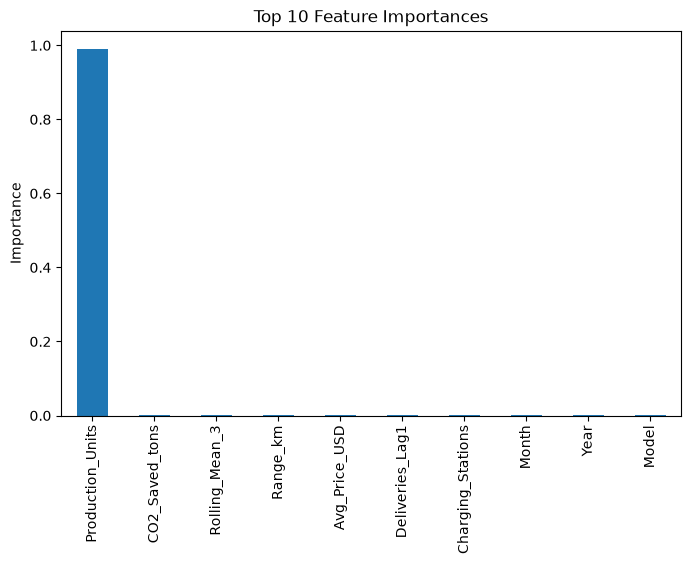

In [64]:
importance = best_rf.feature_importances_

feature_importance = (
    pd.Series(importance, index=X.columns)
    .sort_values(ascending=False)
)
plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances")
plt.ylabel("Importance")
plt.show()

In [65]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Estimated_Deliveries'])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

if result[1] < 0.05:
    print("The series is Stationary")
else:
    print("The series is Non-Stationary")

ADF Statistic : -24.662112249181465
p-value : 0.0
The series is Stationary


In [66]:
forecast = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

forecast['Error %'] = (
    abs(forecast['Actual'] - forecast['Predicted'])
    / forecast['Actual']
) * 100

forecast = forecast.head(20)

print(forecast)

    Actual     Predicted    Error %
0     9476   9063.528804   4.352799
1     8179   8448.374747   3.293492
2    14430  15095.699516   4.613302
3    15912  16210.487814   1.875866
4    15077  14598.067428   3.176577
5    11280  11383.732099   0.919611
6     4070   3964.099473   2.601979
7    11636  11572.280772   0.547604
8    12540  12514.509089   0.203277
9    12717  11842.113838   6.879658
10    5365   5812.506377   8.341219
11   11323  11602.722335   2.470391
12    8624   9025.531449   4.655977
13   11986  11620.625286   3.048346
14   10577  11114.077306   5.077785
15   15370  15066.593333   1.974019
16    2737   3210.865687  17.313324
17   11523  11729.253979   1.789933
18   10530  10169.401971   3.424483
19   11111  10693.937084   3.753604
